In [15]:
import pickle
import pandas as pd

In [2]:
with open('data/results_all.pickle', 'rb') as f:
    results_all = pickle.load(f)

In [6]:
print(results_all[0].keys())

dict_keys(['path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model', 'graph', 'bilstm', 'token', 'graph_a', 'token_a', 'adapter_a', 'non_serializable'])


In [13]:
ser_res = [{k: v for k, v in r.items() if k != 'non_serializable'} for r in results_all]

In [14]:
print(len(ser_res))
print(ser_res[0].keys())

2190
dict_keys(['path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model', 'graph', 'bilstm', 'token', 'graph_a', 'token_a', 'adapter_a'])


In [17]:
df = pd.DataFrame(ser_res)

In [18]:
df.head(10)

,path,guidance_arch,contra,num_guidance_steps,guidance_model,graph,bilstm,token,graph_a,token_a,adapter_a
0,MIDIs/no_guide/gen_jigs85.mid_no,LoRA,True,16,no,0.060721,-0.078383,-0.045905,0.176050,-0.005411,0.055894
1,MIDIs/LoRA/contra/b_A#:7_@2;A:min6_@2/steps_16...,LoRA,True,16,graph,0.134271,-0.086965,-0.060204,0.276061,0.082256,0.146791
2,MIDIs/LoRA/contra/b_A#:7_@2;A:min6_@2/steps_16...,LoRA,True,16,bilstm,0.296205,0.103880,-0.053578,0.209767,0.277058,0.152268
3,MIDIs/LoRA/contra/b_A#:7_@2;A:min6_@2/steps_16...,LoRA,True,16,token,0.317878,0.073085,0.276061,0.453656,0.732634,0.442626
4,MIDIs/LoRA/contra/b_A#:7_@2;A:min6_@2/steps_16...,LoRA,True,16,adapter,0.448158,0.187767,0.324375,0.382279,0.760133,0.441754
5,MIDIs/LoRA/contra/b_A#:7_@2;A:min6_@2/steps_16...,LoRA,True,16,no,0.257837,-0.027267,0.020648,0.177531,0.138226,0.137152
6,MIDIs/LoRA/contra/b_C#:7_@2;C:maj7_@2/steps_16...,LoRA,True,16,graph,0.222444,-0.064625,-0.089860,0.305739,-0.031206,0.092819
7,MIDIs/LoRA/contra/b_C#:7_@2;C:maj7_@2/steps_16...,LoRA,True,16,bilstm,0.215792,-0.018655,-0.158094,0.298675,-0.041432,0.089933
8,MIDIs/LoRA/contra/b_C#:7_@2;C:maj7_@2/steps_16...,LoRA,True,16,token,0.766675,0.152588,0.182882,0.641813,0.537781,0.428185
9,MIDIs/LoRA/contra/b_C#:7_@2;C:maj7_@2/steps_16...,LoRA,True,16,adapter,0.622105,0.111705,0.213799,0.661129,0.666118,0.517188


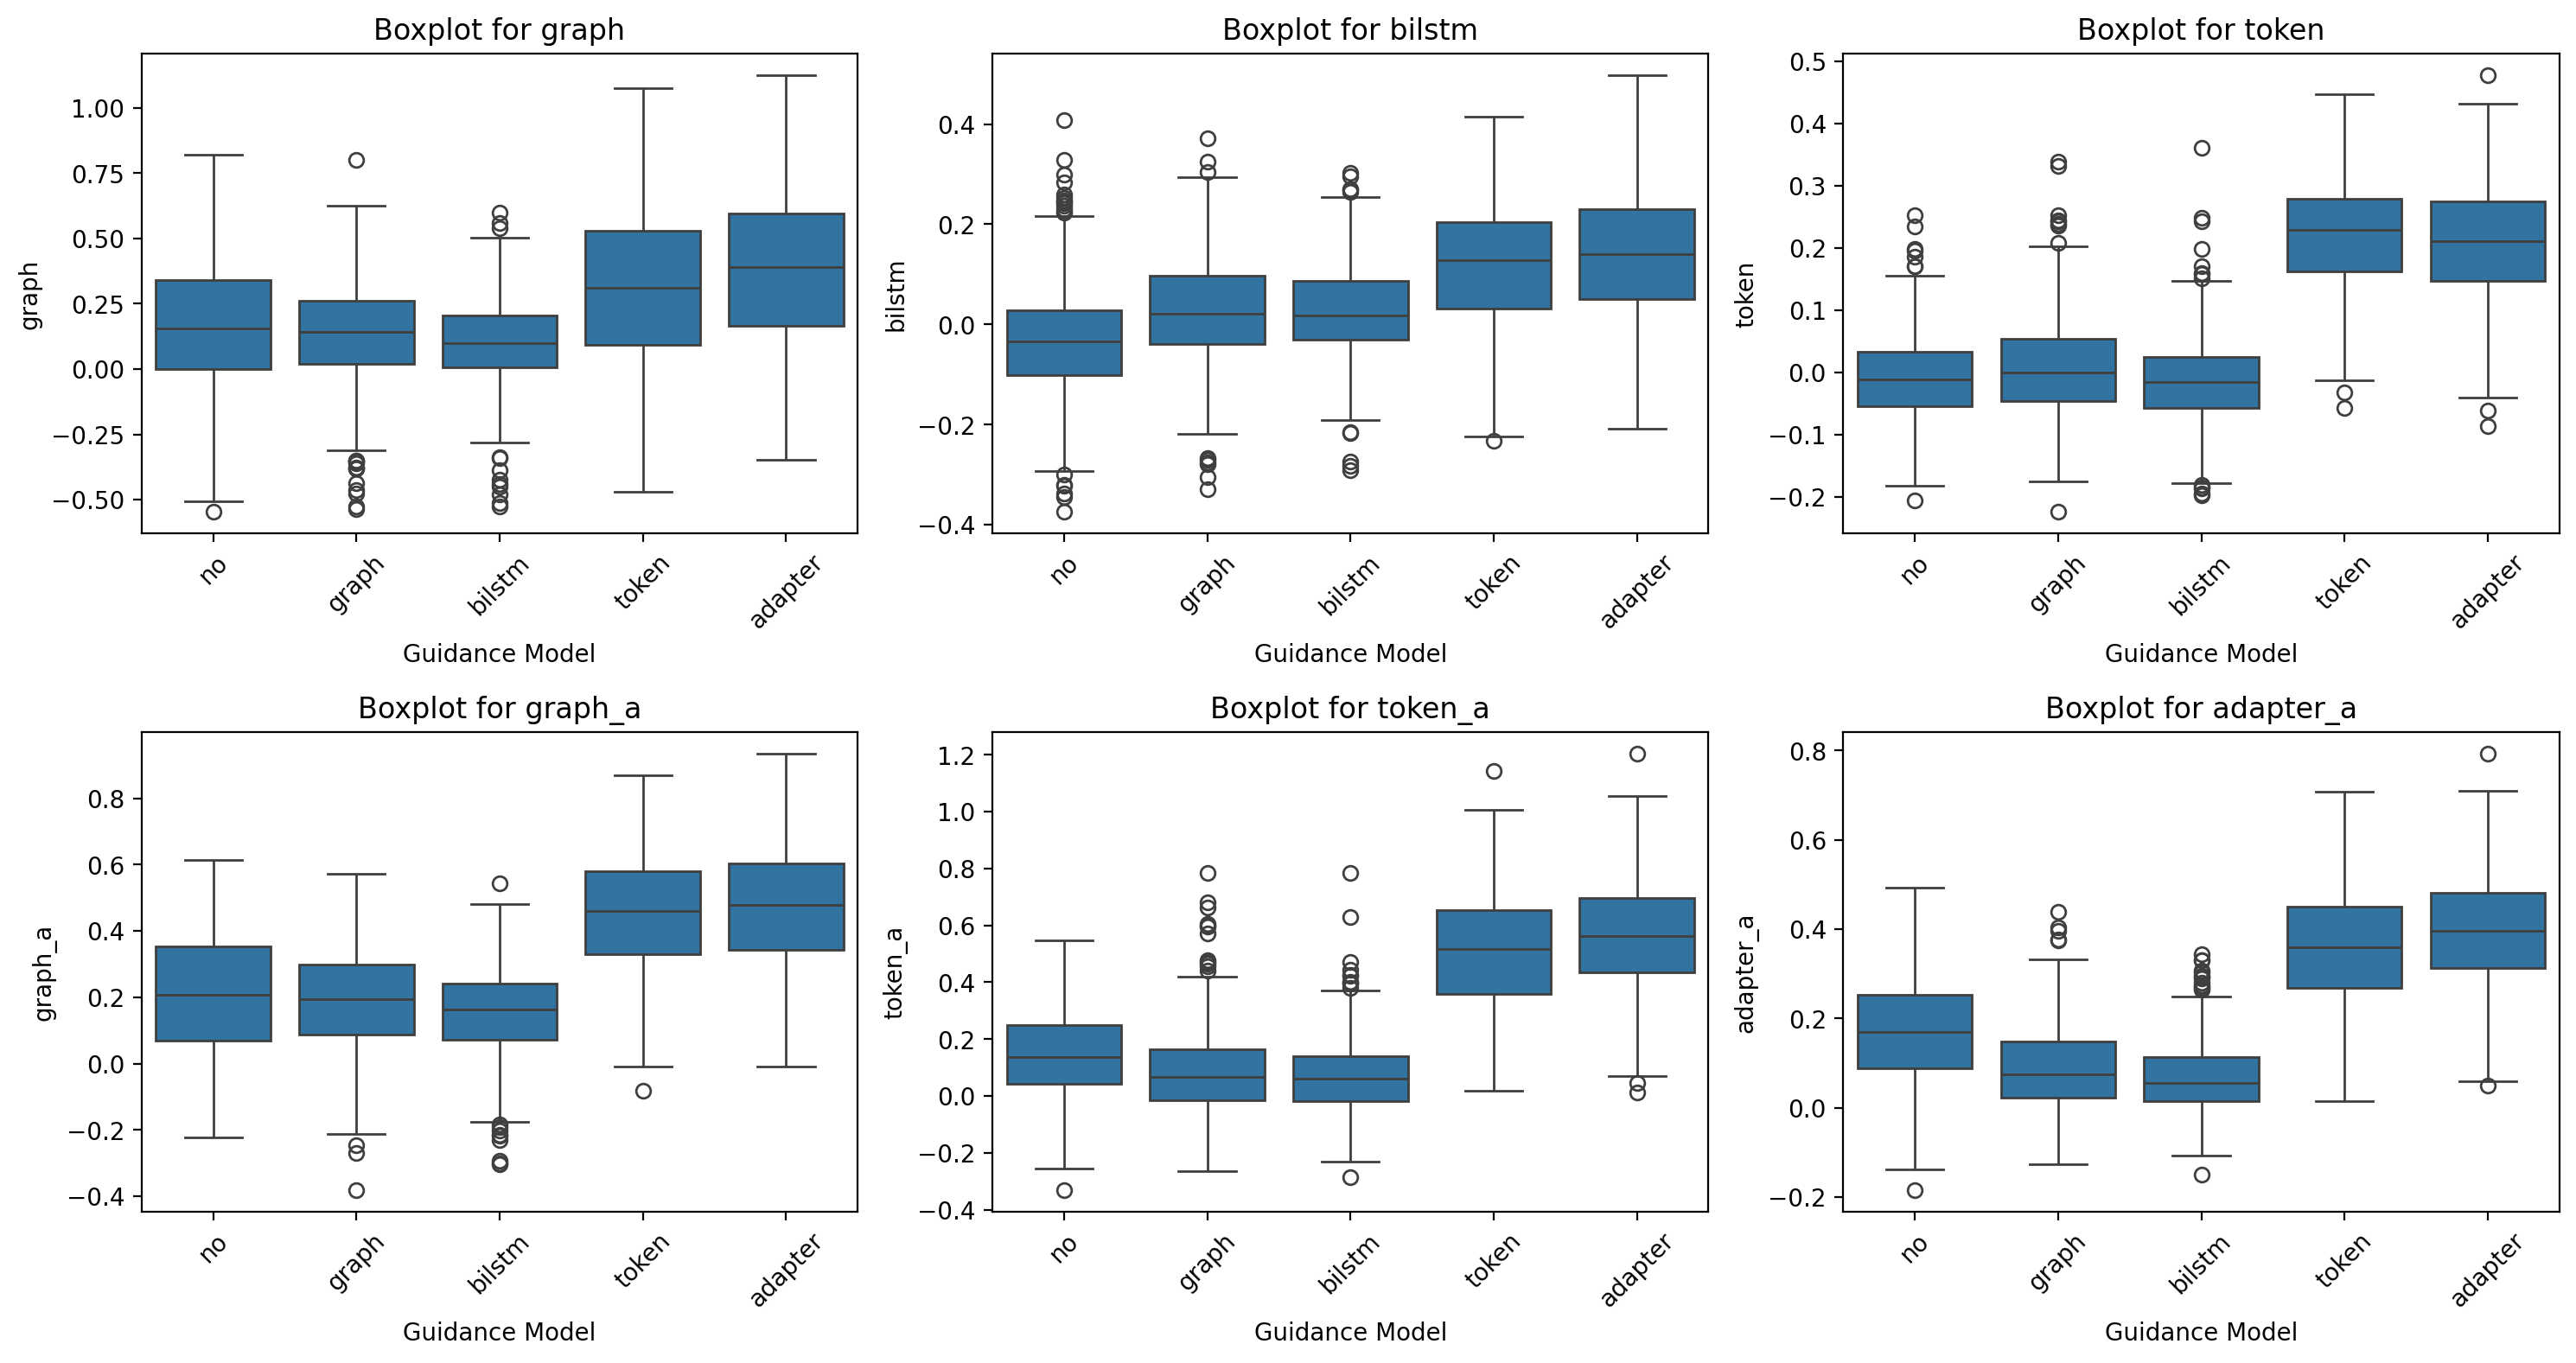

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the last 6 columns (metrics)
metrics = df.columns[-6:].tolist()

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()  # Flatten for easier iteration

for idx, metric in enumerate(metrics):
    sns.boxplot(data=df, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_title(f'Boxplot for {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [21]:
from scipy import stats

metrics = df.columns[-6:].tolist()
models_to_compare = ['token', 'adapter']

df_filtered = df[df['guidance_model'].isin(models_to_compare)]

results = []
for metric in metrics:
    token_data = df_filtered[df_filtered['guidance_model'] == 'token'][metric]
    adapter_data = df_filtered[df_filtered['guidance_model'] == 'adapter'][metric]
    
    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data)
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

      metric  u_statistic   p_value  significant
0      graph      82887.0  0.000499         True
1     bilstm      87267.0  0.020816        False
2      token     102887.0  0.062889        False
3    graph_a      90572.0  0.153101        False
4    token_a      81923.0  0.000185         True
5  adapter_a      82187.0  0.000244         True
